测试数据和训练数据分组，数据分batch

In [25]:
import torch
from joblib import dump, load
from torch_geometric.loader import DataLoader 
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset
# 参数与配置
torch.manual_seed(100)  # 设置随机种子，以使实验结果具有可重复性
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # 有GPU先用GPU训练

# 自定义数据加载器！
class GraphSequenceDataset(Dataset):
    def __init__(self, graph_data, sequence_data):
        assert len(graph_data) == len(sequence_data), "Graph data and sequence data must have the same length."
        self.graph_data = graph_data
        self.sequence_data = sequence_data

    def __len__(self):
        return len(self.graph_data)

    def __getitem__(self, index):
        graph = self.graph_data[index]
        sequence = self.sequence_data[index, :-1].astype(np.float32)
        sequence = torch.tensor(sequence, dtype=torch.float32)
        return graph, sequence


# 加载图数据 和 原始信号数据
def dataloader(batch_size):
    # 训练集
    train_graph_data = load('./dataresult/train_graph_data')
    train_signal_sequences = load('./dataresult/train_set')
    # 验证集
    val_graph_data = load('./dataresult/val_graph_data')
    val_signal_sequences = load('./dataresult/val_set')
    # 测试集
    test_graph_data = load('./dataresult/test_graph_data')
    test_signal_sequences = load('./dataresult/test_set')

    # 创建数据集实例
    train_dataset = GraphSequenceDataset(train_graph_data, train_signal_sequences.values)
    val_dataset = GraphSequenceDataset(val_graph_data, val_signal_sequences.values)
    test_dataset = GraphSequenceDataset(test_graph_data, test_signal_sequences.values)
    # 加载数据
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

    return train_loader, val_loader, test_loader

batch_size = 32
# 加载数据
train_loader, val_loader, test_loader = dataloader(batch_size)

print(len(train_loader))
print(len(val_loader))
print(len(test_loader))

51
15
8


### 定义  Global-Attention 注意力机制

In [26]:
class GlobalAttention(nn.Module):
    def __init__(self, hidden_size):
        super(GlobalAttention, self).__init__()
        self.hidden_size = hidden_size
        self.attn = nn.Linear(hidden_size + hidden_size*2 , hidden_size)
        #对BiGRU输出的全局特征和时间步特征拼接能量向量，送入下个self.v将能量向量变成标量，显示该点权重重要性
        
        self.v = nn.Linear(hidden_size, 1, bias=False)
        #self.v将能量向量变成标量，显示该点权重重要性

    def forward(self, hidden, encoder_outputs):
        max_len = encoder_outputs.size(1)
        # Expand hidden to match the sequence length of encoder_outputs 扩大隐藏层以匹配编码器输出的长度
        repeated_hidden = hidden.unsqueeze(1).repeat(1, max_len, 1)
        # Compute energy scores
        energy = torch.tanh(self.attn(torch.cat((repeated_hidden, encoder_outputs), dim=2)))
        # Compute attention scores
        attention_scores = self.v(energy).squeeze(2)
        # Compute attention weights
        attention_weights = nn.functional.softmax(attention_scores, dim=1)
        # Compute context vector
        context_vector = (encoder_outputs * attention_weights.unsqueeze(2)).sum(dim=1)
        return context_vector

定义 GCN-BiGRU-GATT 分类网络模型

In [27]:
from torch_geometric.nn import GCNConv
import torch.nn.functional as F
from torch_geometric.nn import global_mean_pool


class GCNBiGRUGATTModel(nn.Module):
    def __init__(self, gcn_input_channels, gcn_convLayers, bigru_input_dim, hidden_layer_sizes, num_classes):
        super(GCNBiGRUGATTModel, self).__init__()
       
        """分类任务  params:
        input_channels      : GCN 输入维度数， 特征数量
        gcn_convLayers      : GCN 网络结构 (卷积层通道数)
        bigru_input_dim     : BiGRU 输入维度数
        hidden_layer_sizes  : BiGRU 网络结构 (层数和每层神经元个数)
        num_classes         : 输出的维度,类别数"""

        self.num_classes = num_classes
       # BiGRU参数
        self.num_layers = len(hidden_layer_sizes)  # bigru层数
        self.bigru_layers = nn.ModuleList()  # 用于保存BiGRU层的列表
        # 定义第一层BiGRU
        self.bigru_layers.append(nn.GRU(bigru_input_dim, hidden_layer_sizes[0], batch_first=True, bidirectional=True))
        # 定义后续的BiGRU层
        for i in range(1, self.num_layers):
            self.bigru_layers.append(
                nn.GRU(hidden_layer_sizes[i - 1] * 2, hidden_layer_sizes[i], batch_first=True, bidirectional=True))

        # 定义 全局注意力层  # 注意力层维度 默认为 BiGRU输出层维度
        self.globalAttention = GlobalAttention(hidden_layer_sizes[-1])
            
        # GCN参数
        self.convLayers = gcn_convLayers # GCN 网络结构
        self.input_channels = gcn_input_channels # 输入通道数
        self.gcn_layers = nn.ModuleList()  # 创建一个空的ModuleList来存储GCNConv层

        # 添加GCNConv层
        for hidden_channels in gcn_convLayers:
            self.gcn_layers.append(GCNConv(self.input_channels, hidden_channels))
            self.input_channels = hidden_channels
        
        # 定义投影层对齐维度
        self.projection_gcn = nn.Linear(gcn_convLayers[-1], 512)  # 将GCN特征从256投影到512维
        self.projection_gatt = nn.Linear(hidden_layer_sizes[-1] * 2, 512)  # 保持注意力特征维度为512

        # 定义门控层（输入维度为512 + 512 = 1024）
        self.gate = nn.Sequential(
            nn.Linear(512 + 512, 512),  # 输出维度与特征维度一致
            nn.Sigmoid()
        )

        # 分类器输入维度为512
        # 修改输出层为11类（10个已知类别 + 1个未知类别）
        self.dropout = nn.Dropout(p=0.9)
        self.classifier = nn.Linear(512, num_classes + 1)  # 增加一个未知类别
        
        # 开集识别参数
        self.unknown_threshold = 0.5  # 置信度阈值，用于检测未知类别
        self.unknown_class_idx = num_classes  # 未知类别的索引（第11类）
      
    def forward(self, data, signal_sequence, return_confidence=False):
        batch_size = signal_sequence.size(0)
        
        # 时域特征 送入BiGRU
        bigru_out = signal_sequence.view(batch_size, 32, 32)  # torch.Size([32, 32, 32])
        # 送入BiGRU层
        hidden = []
        for bigru in self.bigru_layers:
            bigru_out, hidden = bigru(bigru_out)

        # 送入全局注意力层
        gatt_features = self.globalAttention(hidden[-1], bigru_out)  # torch.Size([32, 128])

        # 空间特征：GCN
        x, edge_index, batch = data.x, data.edge_index, data.batch
        # 送入 GCN网络
        for gcnconv in self.gcn_layers:
            x = gcnconv(x, edge_index)
            x = F.relu(x)
        gcn_features = global_mean_pool(x, batch)  # 对每个批次的结果进行池化操作

        # 模型堆叠，门控融合
        projected_gcn = self.projection_gcn(gcn_features)  # [32, 512]
        projected_gatt = self.projection_gatt(gatt_features)  # [32, 512]

        # 生成门控值
        concat_features = torch.cat((projected_gcn, projected_gatt), dim=1)
        gate_values = self.gate(concat_features)  # [32, 512]

        # 门控融合
        combined_features = gate_values * projected_gcn + (1 - gate_values) * projected_gatt

        # 分类器输出
        logits = self.classifier(combined_features)  # torch.Size([32, 11]
        
        # 如果需要返回置信度信息（用于开集识别）
        if return_confidence:
            # 计算置信度（最大概率值）
            probabilities = F.softmax(logits, dim=1)
            confidences, _ = torch.max(probabilities, dim=1)
            return logits, confidences
        
        return logits
    
    # 开集识别方法：基于置信度阈值检测未知类别
    def predict_with_confidence(self, data, signal_sequence):
        # 获取原始logits和置信度
        logits, confidences = self.forward(data, signal_sequence, return_confidence=True)
        
        # 获取预测类别
        predicted_labels = torch.argmax(logits, dim=1)
        
        # 应用置信度阈值检测未知类别
        # 当置信度低于阈值时，将预测类别设为未知类别
        predicted_labels[confidences < self.unknown_threshold] = self.unknown_class_idx
        
        return predicted_labels, confidences



In [28]:
# 定义模型参数
# GCN 网络结构
gcn_convLayers = (64, 128,256) 
gcn_input_channels = 33 # 输入维度为1 ，一维信号
num_classes = 10

input_dim = 1024      # 信号序列总长度（32*32）
seq_len = 32          # 序列长度
hidden_size = 128     # 与原始GRU的隐藏层大小对齐
num_classes = 10

# BiGRU 网络参数
hidden_layer_sizes = [64, 128,256]  # GRU 层数和维度数
bigru_input_dim = 32  # 注意：这里是 把数据进行了堆叠 把一个1*1024 的矩阵 进行 划分堆叠成形状为 32 * 32， 就使输入序列的长度降下来了

# 修改为11类输出（10个已知类别 + 1个未知类别）
model = GCNBiGRUGATTModel(gcn_input_channels, gcn_convLayers, bigru_input_dim, hidden_layer_sizes, num_classes)  
# 定义损失函数和优化函数 - 添加权重处理未知类别
# 假设已知类别权重为1，未知类别权重为2（根据实际情况调整）
class_weights = torch.ones(num_classes + 1)  # 11个类别的权重
class_weights[-1] = 2.0  # 为未知类别设置更高权重
class_weights = class_weights.to(device)

loss_function = nn.CrossEntropyLoss(weight=class_weights, reduction='sum')  # 带权重的损失函数
loss_function = loss_function.to(device)

# 自动调整学习率
learn_rate = 0.003
optimizer = torch.optim.Adam(model.parameters(), lr=learn_rate, weight_decay=0.001)
# 添加ReduceLROnPlateau调度器，根据验证损失调整学习率
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.3, patience=5, verbose=True)

# 看下这个网络结构总共有多少个参数
def count_parameters(model):
    params = [p.numel() for p in model.parameters() if p.requires_grad]
    for item in params:
        print(f'{item:>6}')
    print(f'______\n{sum(params):>6}')

count_parameters(model)# 训练模型

  6144
 12288
   192
   192
  6144
 12288
   192
   192
 49152
 49152
   384
   384
 49152
 49152
   384
   384
196608
196608
   768
   768
196608
196608
   768
   768
196608
   256
   256
    64
  2112
   128
  8192
   256
 32768
131072
   512
262144
   512
524288
   512
  5632
    11
______
2190603


In [29]:
print(model)

GCNBiGRUGATTModel(
  (bigru_layers): ModuleList(
    (0): GRU(32, 64, batch_first=True, bidirectional=True)
    (1): GRU(128, 128, batch_first=True, bidirectional=True)
    (2): GRU(256, 256, batch_first=True, bidirectional=True)
  )
  (globalAttention): GlobalAttention(
    (attn): Linear(in_features=768, out_features=256, bias=True)
    (v): Linear(in_features=256, out_features=1, bias=False)
  )
  (gcn_layers): ModuleList(
    (0): GCNConv(33, 64)
    (1): GCNConv(64, 128)
    (2): GCNConv(128, 256)
  )
  (projection_gcn): Linear(in_features=256, out_features=512, bias=True)
  (projection_gatt): Linear(in_features=512, out_features=512, bias=True)
  (gate): Sequential(
    (0): Linear(in_features=1024, out_features=512, bias=True)
    (1): Sigmoid()
  )
  (dropout): Dropout(p=0.9, inplace=False)
  (classifier): Linear(in_features=512, out_features=11, bias=True)
)


注意调整参数，
1. 可以适当增加 GCN层数 和每层神经元个数，微调学习率；
2. 增加更多的 epochs,  （注意防止过拟合）

Epoch:  1 train_Loss: 1.74624613 train_Accuracy:0.2960
Epoch:  1 val_Loss:1.04081630,  validate_Acc:0.5479
  Known Classes Accuracy: 0.3884
Epoch: 1, Current LR: 3.00e-03
Epoch:  2 train_Loss: 0.82962082 train_Accuracy:0.6869
Epoch:  2 val_Loss:0.71216065,  validate_Acc:0.6813
  Known Classes Accuracy: 0.5215
Epoch: 2, Current LR: 3.00e-03
Epoch:  3 train_Loss: 0.43622754 train_Accuracy:0.8517
Epoch:  3 val_Loss:0.71414306,  validate_Acc:0.7500
  Known Classes Accuracy: 0.7468
Epoch: 3, Current LR: 3.00e-03
Epoch:  4 train_Loss: 0.27683057 train_Accuracy:0.9081
Epoch:  4 val_Loss:0.15971955,  validate_Acc:0.9125
  Known Classes Accuracy: 0.9356
Epoch: 4, Current LR: 3.00e-03
Epoch:  5 train_Loss: 0.11777443 train_Accuracy:0.9571
Epoch:  5 val_Loss:0.09722261,  validate_Acc:0.9375
  Known Classes Accuracy: 0.9657
Epoch: 5, Current LR: 3.00e-03
Epoch:  6 train_Loss: 0.04438271 train_Accuracy:0.9841
Epoch:  6 val_Loss:0.02740855,  validate_Acc:0.9604
  Known Classes Accuracy: 0.9893
Epoch

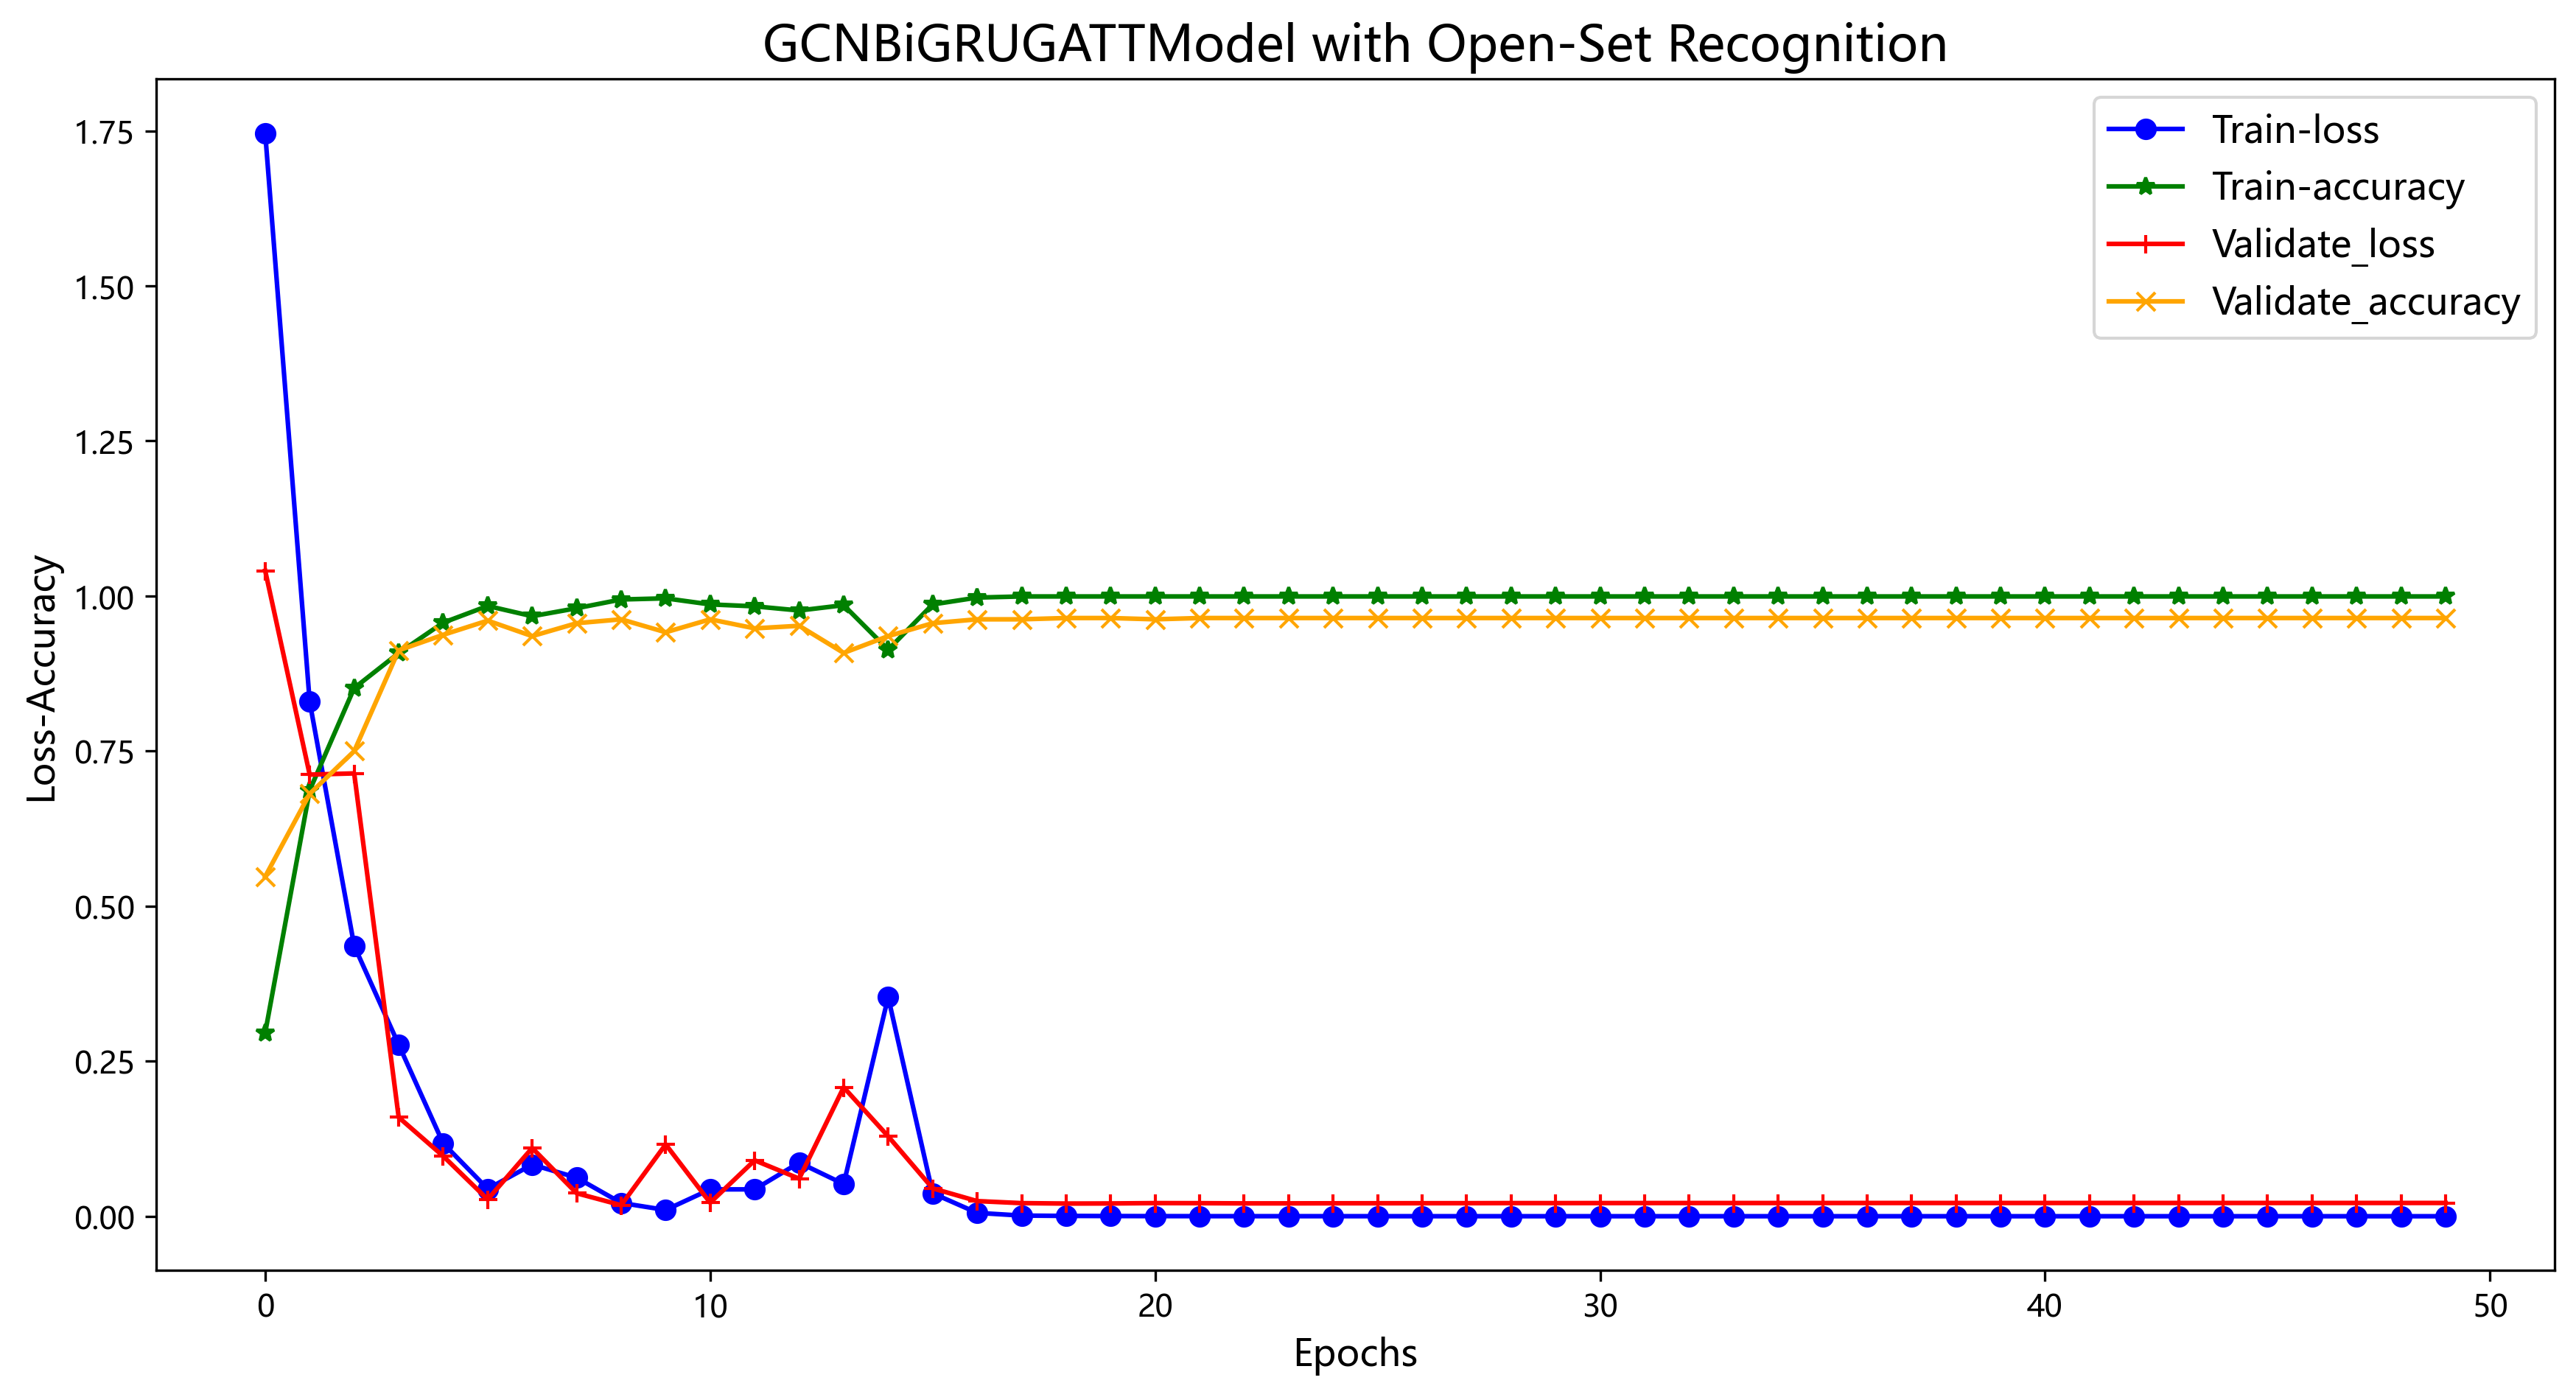

best_accuracy : 0.9645833333333333


In [30]:
# 训练模型
import time
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rc("font", family='Microsoft YaHei')

def model_train(batch_size, epochs, train_loader, val_loader, model, optimizer, loss_function, device, scheduler):
    model = model.to(device)
    # 样本长度
    train_size = len(train_loader) * batch_size
    val_size = len(val_loader) * batch_size

    # 最高准确率  最佳模型
    best_accuracy = 0.0
    best_model = model

    train_loss = []     # 记录在训练集上每个epoch的loss的变化情况
    train_acc = []    # 记录在训练集上每个epoch的准确率的变化情况
    validate_acc = []
    validate_loss = []

    # 计算模型运行时间
    start_time = time.time()
   
    for epoch in range(epochs):
        # 训练
        model.train()
        loss_epoch = 0.    #保存当前epoch的loss和
        correct_epoch = 0  #保存当前epoch的正确个数和
        for batchdata  in train_loader: 
            graph_data, signal_sequence = batchdata
            graph_data, signal_sequence = graph_data.to(device),  signal_sequence.to(device) # 将数据移动到设备
            # 每次更新参数前都梯度归零和初始化
            optimizer.zero_grad()
            # 前向传播
            y_pred = model(graph_data, signal_sequence)  
            # 对模型输出进行softmax操作，得到概率分布
            probabilities = F.softmax(y_pred, dim=1)
            # 得到预测的类别
            predicted_labels = torch.argmax(probabilities, dim=1)
            # 与真实标签进行比较，计算预测正确的样本数量  # 计算当前batch预测正确个数
            correct_epoch += (predicted_labels == graph_data.y).sum().item()
            # 损失计算
            loss = loss_function(y_pred, graph_data.y)
            loss_epoch += loss.item()
            # 反向传播和参数更新
            loss.backward()
            optimizer.step()
            
        # 计算准确率
        train_Accuracy  = correct_epoch/train_size 
        train_loss.append(loss_epoch/train_size)
        train_acc.append(train_Accuracy)
        print(f'Epoch: {epoch+1:2} train_Loss: {loss_epoch/train_size:10.8f} train_Accuracy:{train_Accuracy:4.4f}')
        
        # 验证阶段
        with torch.no_grad():
            model.eval()
            loss_validate = 0.
            correct_validate = 0
            # 用于开集识别评估的统计量
            known_correct = 0
            unknown_correct = 0
            known_total = 0
            unknown_total = 0
            
            for valbatch in val_loader:
                graph_data, signal_sequence = valbatch
                graph_data, signal_sequence = graph_data.to(device),  signal_sequence.to(device) # 将数据移动到设备
                pre = model(graph_data, signal_sequence)
                # 对模型输出进行softmax操作，得到概率分布
                probabilities = F.softmax(pre, dim=1)
                # 得到预测的类别
                predicted_labels = torch.argmax(probabilities, dim=1)
                # 计算置信度（最大概率值）
                confidences, _ = torch.max(probabilities, dim=1)
                
                # 开集识别：应用置信度阈值
                predicted_open_set = predicted_labels.clone()
                predicted_open_set[confidences < model.unknown_threshold] = model.unknown_class_idx
                
                # 统计验证集上的正确率
                correct_validate += (predicted_labels == graph_data.y).sum().item()
                loss = loss_function(pre, graph_data.y)
                loss_validate += loss.item()
                
                # 开集识别性能评估
                # 分离已知类别和未知类别
                known_mask = graph_data.y < num_classes
                unknown_mask = graph_data.y == num_classes
                
                # 已知类别统计
                if known_mask.any():
                    known_total += known_mask.sum().item()
                    known_correct += (predicted_open_set[known_mask] == graph_data.y[known_mask]).sum().item()
                
                # 未知类别统计
                if unknown_mask.any():
                    unknown_total += unknown_mask.sum().item()
                    unknown_correct += (predicted_open_set[unknown_mask] == model.unknown_class_idx).sum().item()
            
            # 计算整体准确率
            val_accuracy = correct_validate/val_size 
            print(f'Epoch: {epoch+1:2} val_Loss:{loss_validate/val_size:10.8f},  validate_Acc:{val_accuracy:4.4f}')
            
            # 计算开集识别性能
            if known_total > 0:
                known_acc = known_correct / known_total
                print(f'  Known Classes Accuracy: {known_acc:.4f}')
            if unknown_total > 0:
                unknown_acc = unknown_correct / unknown_total
                print(f'  Unknown Classes Detection Rate: {unknown_acc:.4f}')
            
            print(f"Epoch: {epoch+1}, Current LR: {optimizer.param_groups[0]['lr']:.2e}")
            validate_loss.append(loss_validate/val_size)
            validate_acc.append(val_accuracy)
            
            # 更新学习率
            if scheduler is not None:
                scheduler.step(loss_validate / val_size)  # 传入验证损失用于调整学习率
            
            # 保存当前最优模型参数
            if val_accuracy > best_accuracy:
                best_accuracy = val_accuracy
                best_model = model  # 更新最佳模型的参数

    # 保存最好的参数
    torch.save(best_model, 'best_model_gcn_bigru_gatt_open_set.pt')
   
    # 可视化
    plt.figure(figsize=(14, 7), dpi=300)
    plt.plot(range(epochs), train_loss, color='blue', marker='o', label='Train-loss')
    plt.plot(range(epochs), train_acc, color='green', marker='*', label='Train-accuracy')
    plt.plot(range(epochs), validate_loss, color='red', marker='+', label='Validate_loss')
    plt.plot(range(epochs), validate_acc, color='orange', marker='x', label='Validate_accuracy')

    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss-Accuracy', fontsize=12)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.legend(fontsize=12)
    plt.title('GCNBiGRUGATTModel with Open-Set Recognition', fontsize=16)
    plt.show()
    
    # 保存结果
    dump(train_loss, './dataresult/train_loss_open_set')
    dump(train_acc, './dataresult/train_acc_open_set')
    dump(validate_loss, './dataresult/validate_loss_open_set')
    dump(validate_acc, './dataresult/validate_acc_open_set')

    print("best_accuracy :", best_accuracy)


batch_size = 32
epochs = 50
# 模型训练
model_train(batch_size, epochs, train_loader, val_loader, model, optimizer, loss_function, device, scheduler)

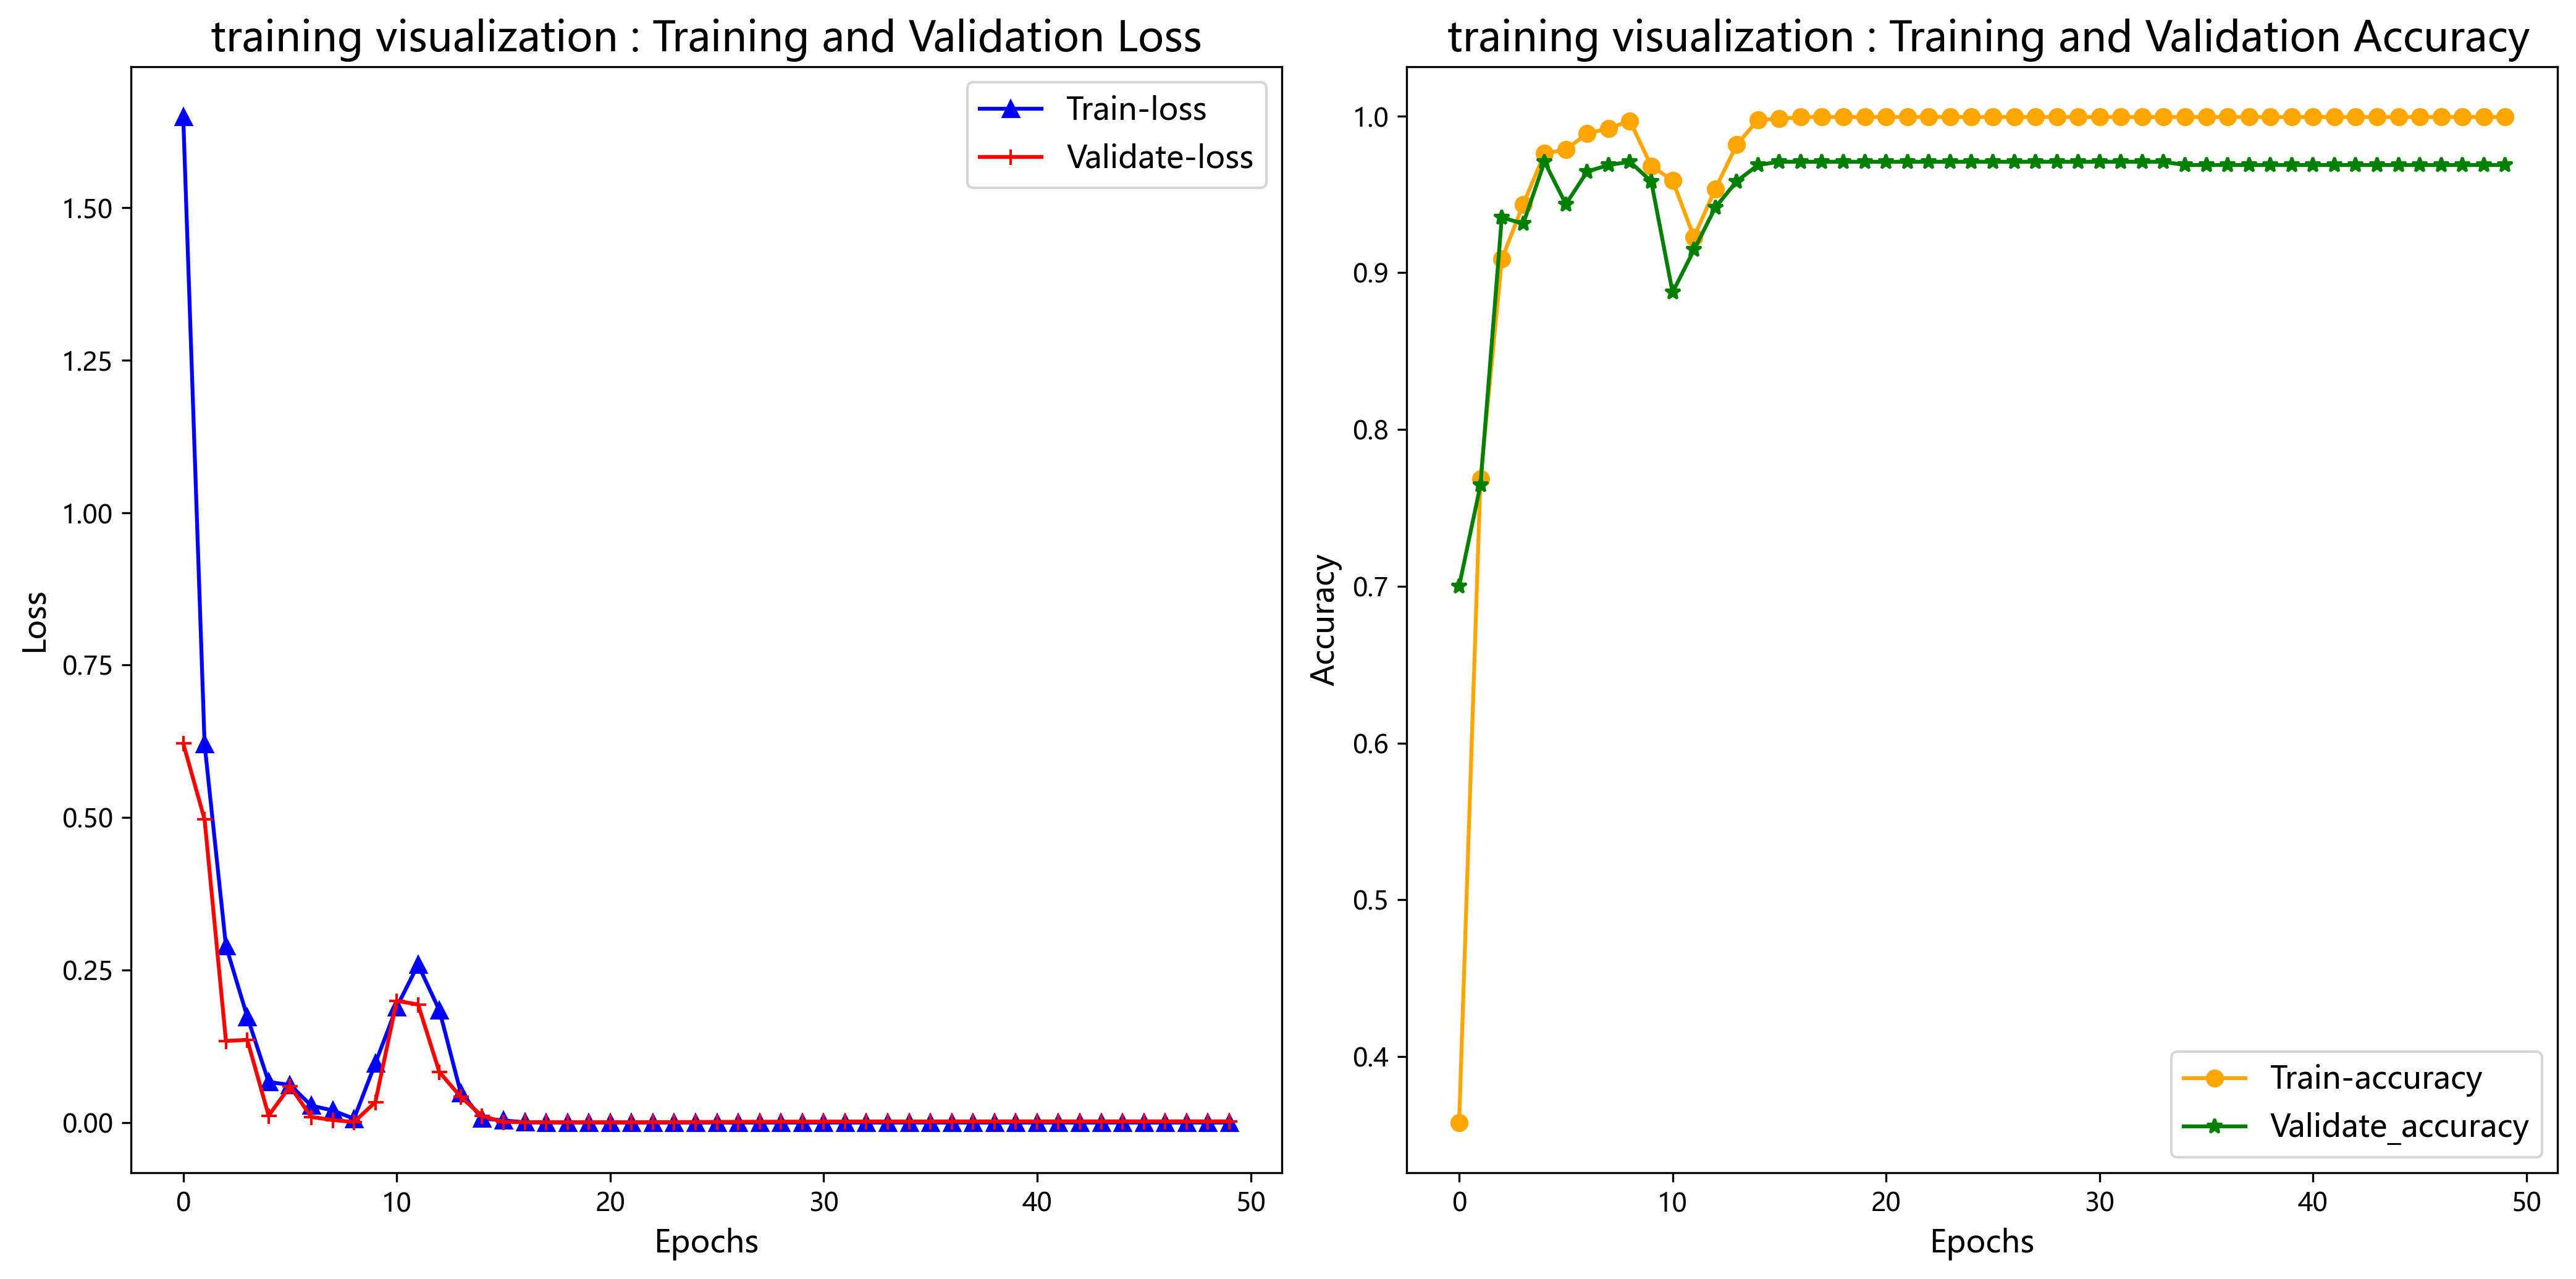

In [31]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from joblib import dump, load
matplotlib.rc("font", family='Microsoft YaHei')

# 加载数据
train_loss = load('./dataresult/train_loss')
train_acc = load('./dataresult/train_acc')

validate_loss = load('./dataresult/validate_loss')
validate_acc = load('./dataresult/validate_acc')

# 创建训练损失图
# 创建左侧图：损失
plt.figure(figsize=(14, 7), dpi=300)

plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Train-loss', marker='^', color='blue') # o ^ * s + x   , marker='o'
plt.plot(validate_loss, label='Validate-loss', marker='+', color='red')   # 颜色 曲线类型 可灵活替换
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=12)
plt.title('training visualization : Training and Validation Loss', fontsize=16)

# 创建右侧图：准确率
plt.subplot(1, 2, 2)
plt.plot(train_acc,color = 'orange', marker='o',label = 'Train-accuracy')
plt.plot(validate_acc, color = 'green', marker='*',label = 'Validate_accuracy')


plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=12)
plt.title(' training visualization : Training and Validation Accuracy', fontsize=16)


plt.tight_layout()  # 用于确保子图之间的距离适当
plt.show()

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        26
           1     1.0000    1.0000    1.0000        27
           2     1.0000    1.0000    1.0000        20
           3     1.0000    1.0000    1.0000        24
           4     1.0000    1.0000    1.0000        22
           5     1.0000    1.0000    1.0000        24
           6     1.0000    1.0000    1.0000        22
           7     1.0000    1.0000    1.0000        17
           8     1.0000    1.0000    1.0000        22
           9     1.0000    1.0000    1.0000        29

    accuracy                         1.0000       233
   macro avg     1.0000    1.0000    1.0000       233
weighted avg     1.0000    1.0000    1.0000       233



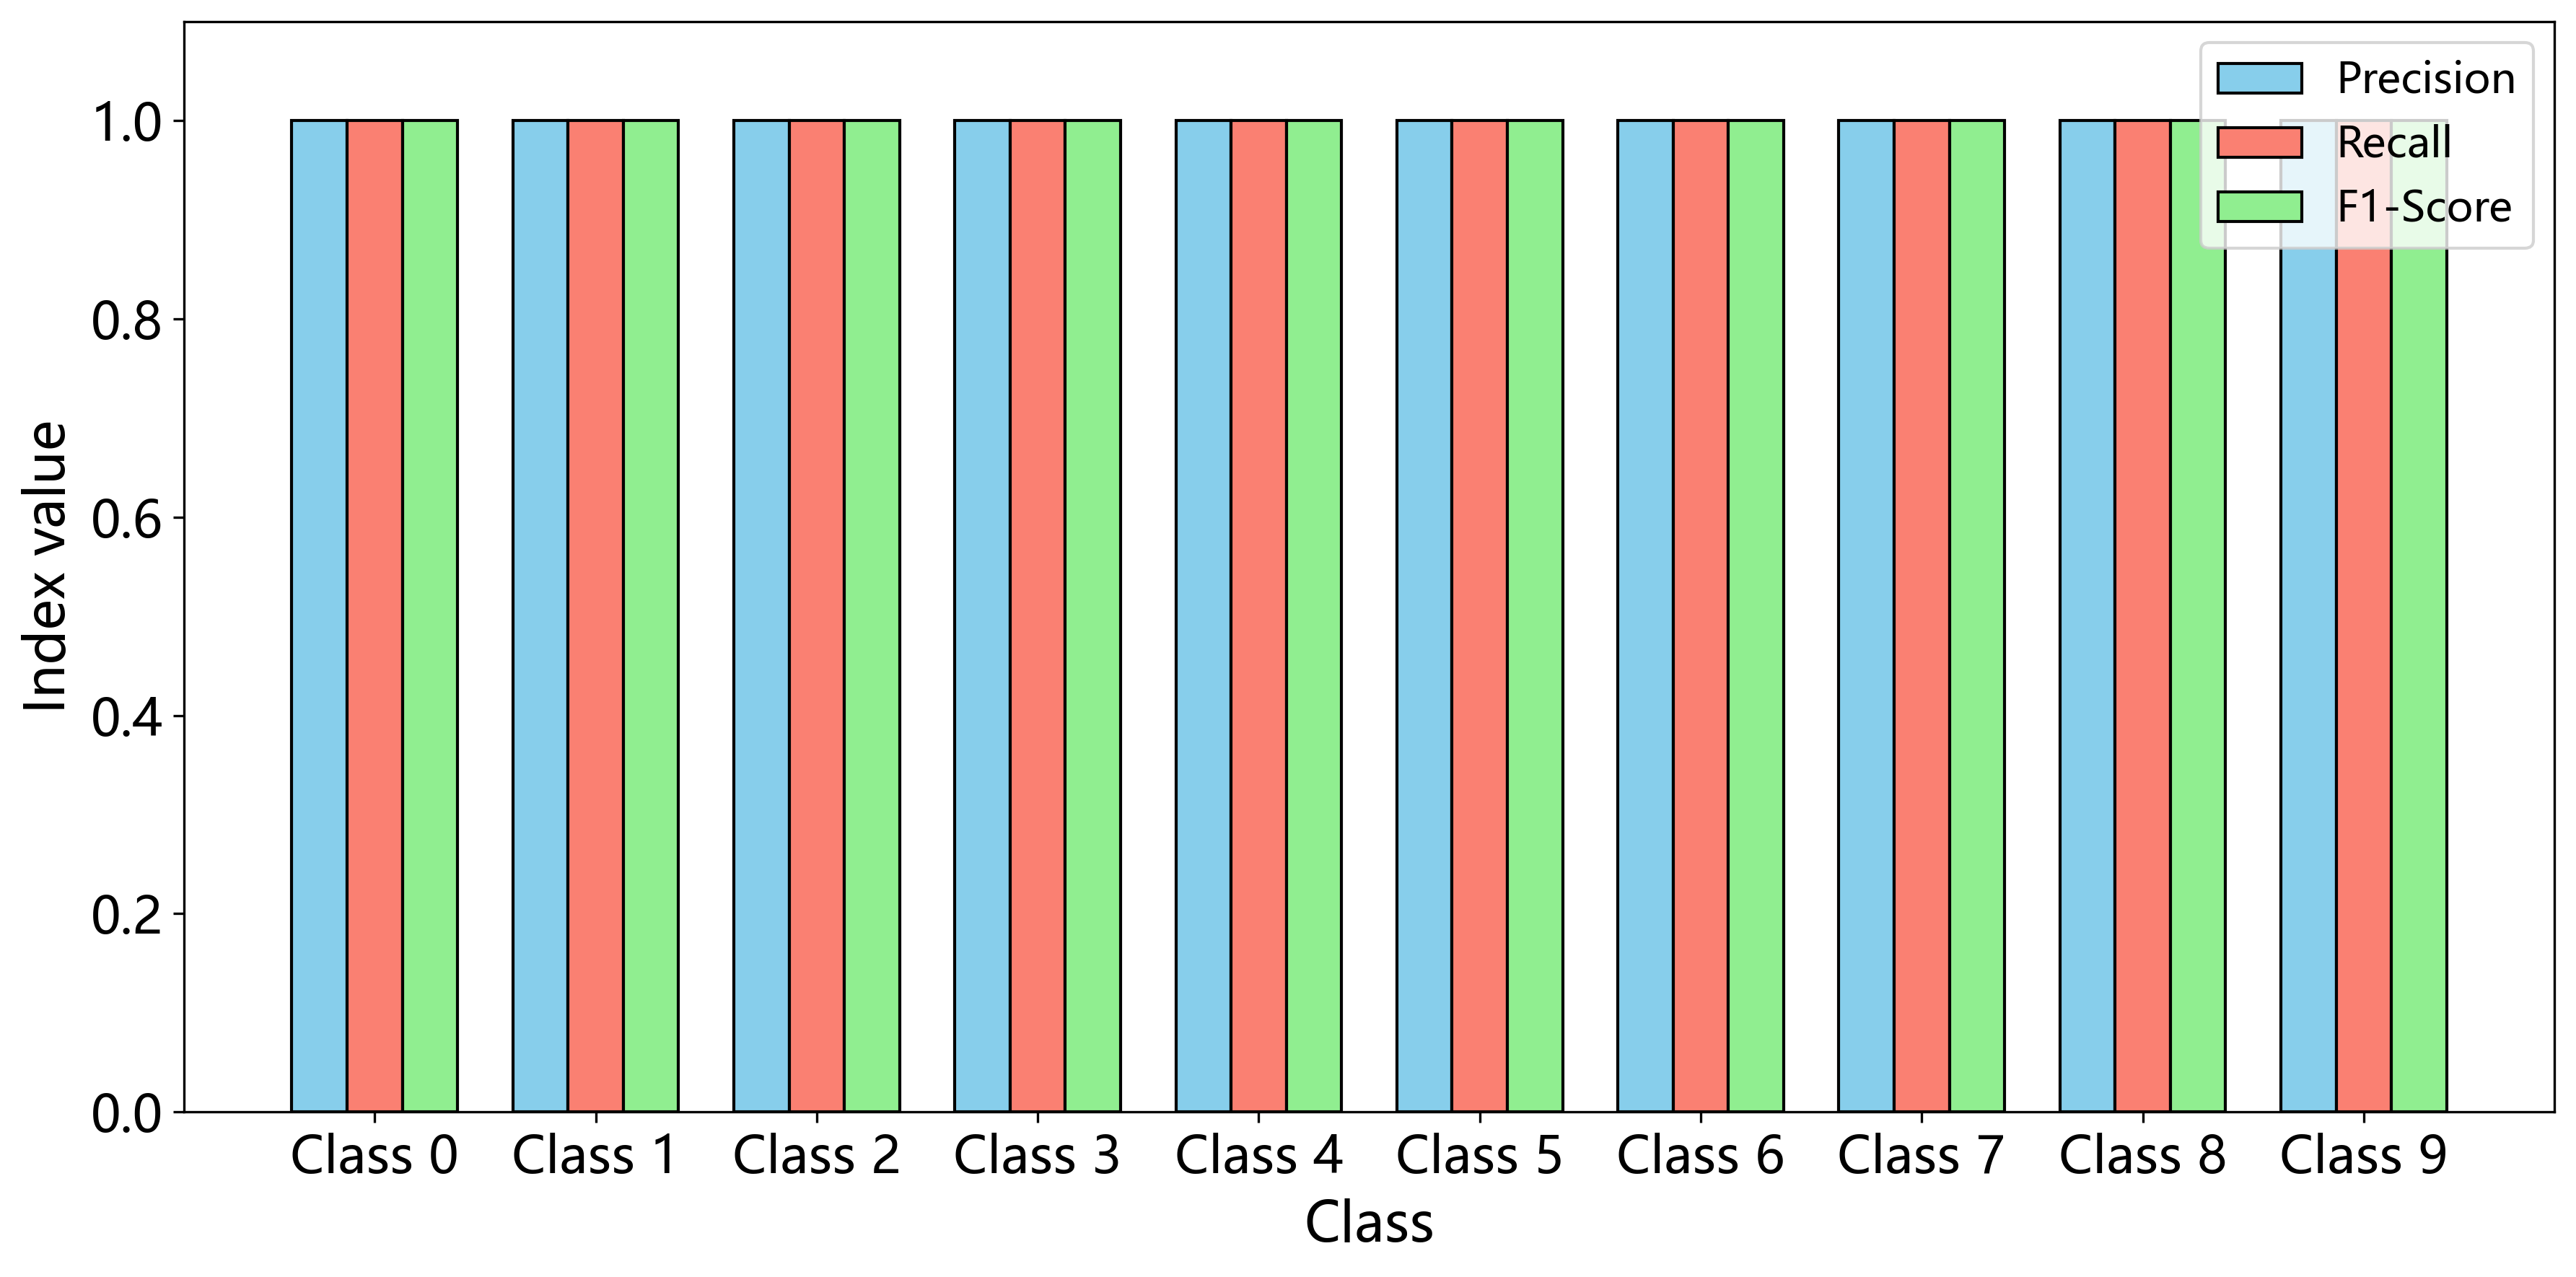

In [32]:

import torch
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix


# 模型 测试集 验证  
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # 有GPU先用GPU训练
#得出每一类的分类准确率
model = torch.load('best_model_gcn_bigru_gatt.pt')
model = model.to(device)

# 使用测试集数据进行推断并计算每一类的分类准确率
true_labels = []  # 存储类别标签
predicted_labels = []  # 存储预测的标签

# 提取特征
test_original_features = []  # 原始测试集 特征
test_model_features = []  # 测试集经过训练后的模型得到的 特征

with torch.no_grad():
    for testbatch in test_loader:
        graph_data, signal_sequence = testbatch
        test_original_features += signal_sequence.tolist()# 提取原始特征
        # 将模型设置为评估模式
        model.eval()
        graph_data, signal_sequence = graph_data.to(device),  signal_sequence.to(device) # 将数据移动到设备
        test_output = model(graph_data, signal_sequence)
        test_model_features += test_output.tolist()  # 提取特征

        probabilities = F.softmax(test_output, dim=1)
        predicted = torch.argmax(probabilities, dim=1)
        
        true_labels.extend(graph_data.y.tolist())
        predicted_labels.extend(predicted.tolist())

# 混淆矩阵
confusion_mat = confusion_matrix(true_labels, predicted_labels)

from sklearn.metrics import classification_report
# 计算每一类的分类准确率
report = classification_report(true_labels, predicted_labels, digits=4)
print(report)
# 计算每一类的分类准确率和召回率
report = classification_report(true_labels, predicted_labels, output_dict=True, digits=4)


# 提取分类指标
categories = []
precision = []
recall = []
f1_score = []

for key, value in report.items():
    if key.isdigit():
        categories.append(f'Class {key}')
        precision.append(round(value['precision'], 2))
        recall.append(round(value['recall'], 2))
        f1_score.append(round(value['f1-score'], 2))

# 设置柱状图位置和宽度
x = np.arange(len(categories))  # 类别标签的x位置
width = 0.25  # 柱子宽度

# 绘制多柱状图
plt.figure(figsize=(12, 6), dpi=300)
plt.bar(x - width, precision, width, label='Precision', color='skyblue', edgecolor='black')
plt.bar(x, recall, width, label='Recall', color='salmon', edgecolor='black')
plt.bar(x + width, f1_score, width, label='F1-Score', color='lightgreen', edgecolor='black')

# 添加标签和标题
plt.xlabel('Class', fontsize=18)
plt.ylabel('Index value', fontsize=18)
#plt.title('Comparison of classification indicators of various categories', fontsize=12)
plt.xticks(x, categories, fontsize=17)
plt.yticks(fontsize=17)
plt.ylim(0, 1.1)
plt.legend(fontsize=14)

'''
# 在柱状图上显示数值
for i in range(len(categories)):
    plt.text(i - width, precision[i] + 0.02, f'{precision[i]:.2f}', ha='center', fontsize=7)
    plt.text(i, recall[i] + 0.02, f'{recall[i]:.2f}', ha='center', fontsize=7)
    plt.text(i + width, f1_score[i] + 0.02, f'{f1_score[i]:.2f}', ha='center', fontsize=7)
'''
plt.tight_layout()
plt.show()
# 修改部分结束

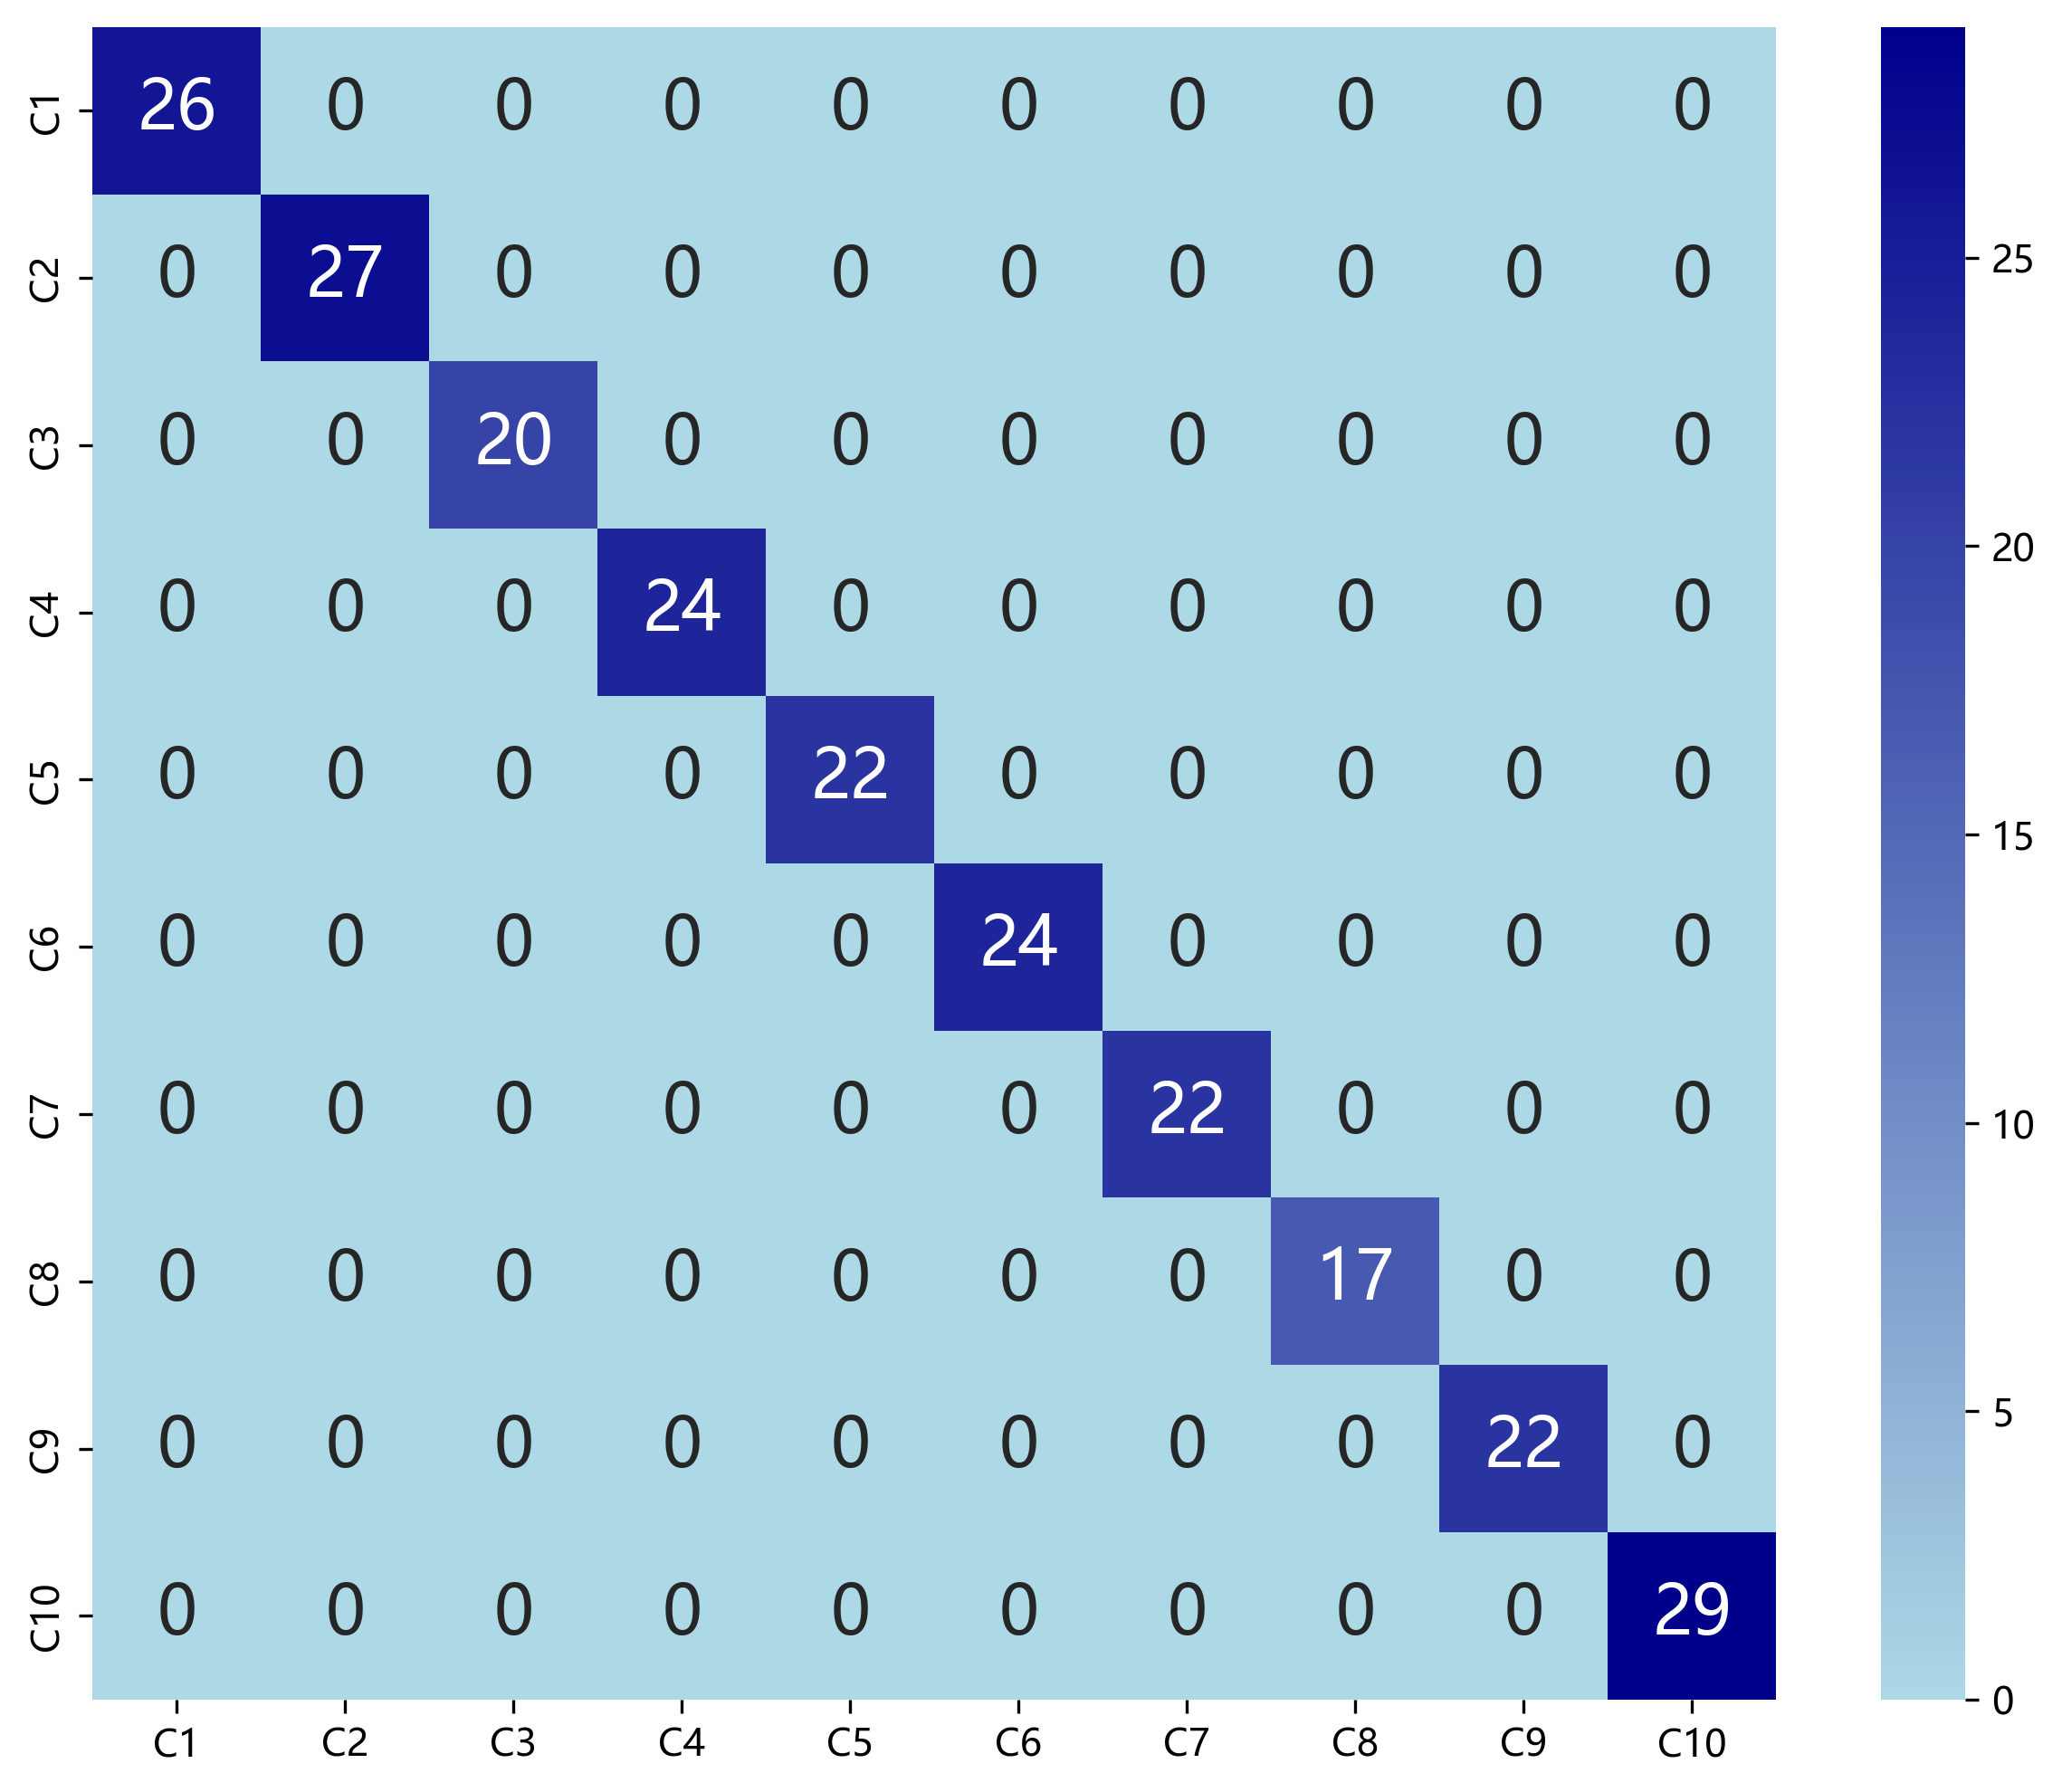

In [36]:
# 绘制混淆矩阵
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
# 原始标签和自定义标签的映射
label_mapping = {
    0: "C1",1: "C2",2: "C3",3: "C4",4: "C5",
    5: "C6",6: "C7",7: "C8",8: "C9",9: "C10",
}


# 自定义颜色映射：从浅蓝色到深蓝色
colors = ["#ADD8E6", "#00008B"]  # 浅蓝色 (#ADD8E6) 到深蓝色 (#0000FF)
cmap = LinearSegmentedColormap.from_list("custom_blues", colors)


# 绘制混淆矩阵
plt.figure(figsize=(10, 8), dpi=300)
sns.heatmap(confusion_mat,  xticklabels=label_mapping.values(), yticklabels=label_mapping.values(),annot=True,annot_kws={'size': 18}, fmt='d', cmap=cmap)
# plt.xlabel('Predicted Labels')
# plt.ylabel('True Labels')
# plt.title('Confusion Matrix')
plt.show()

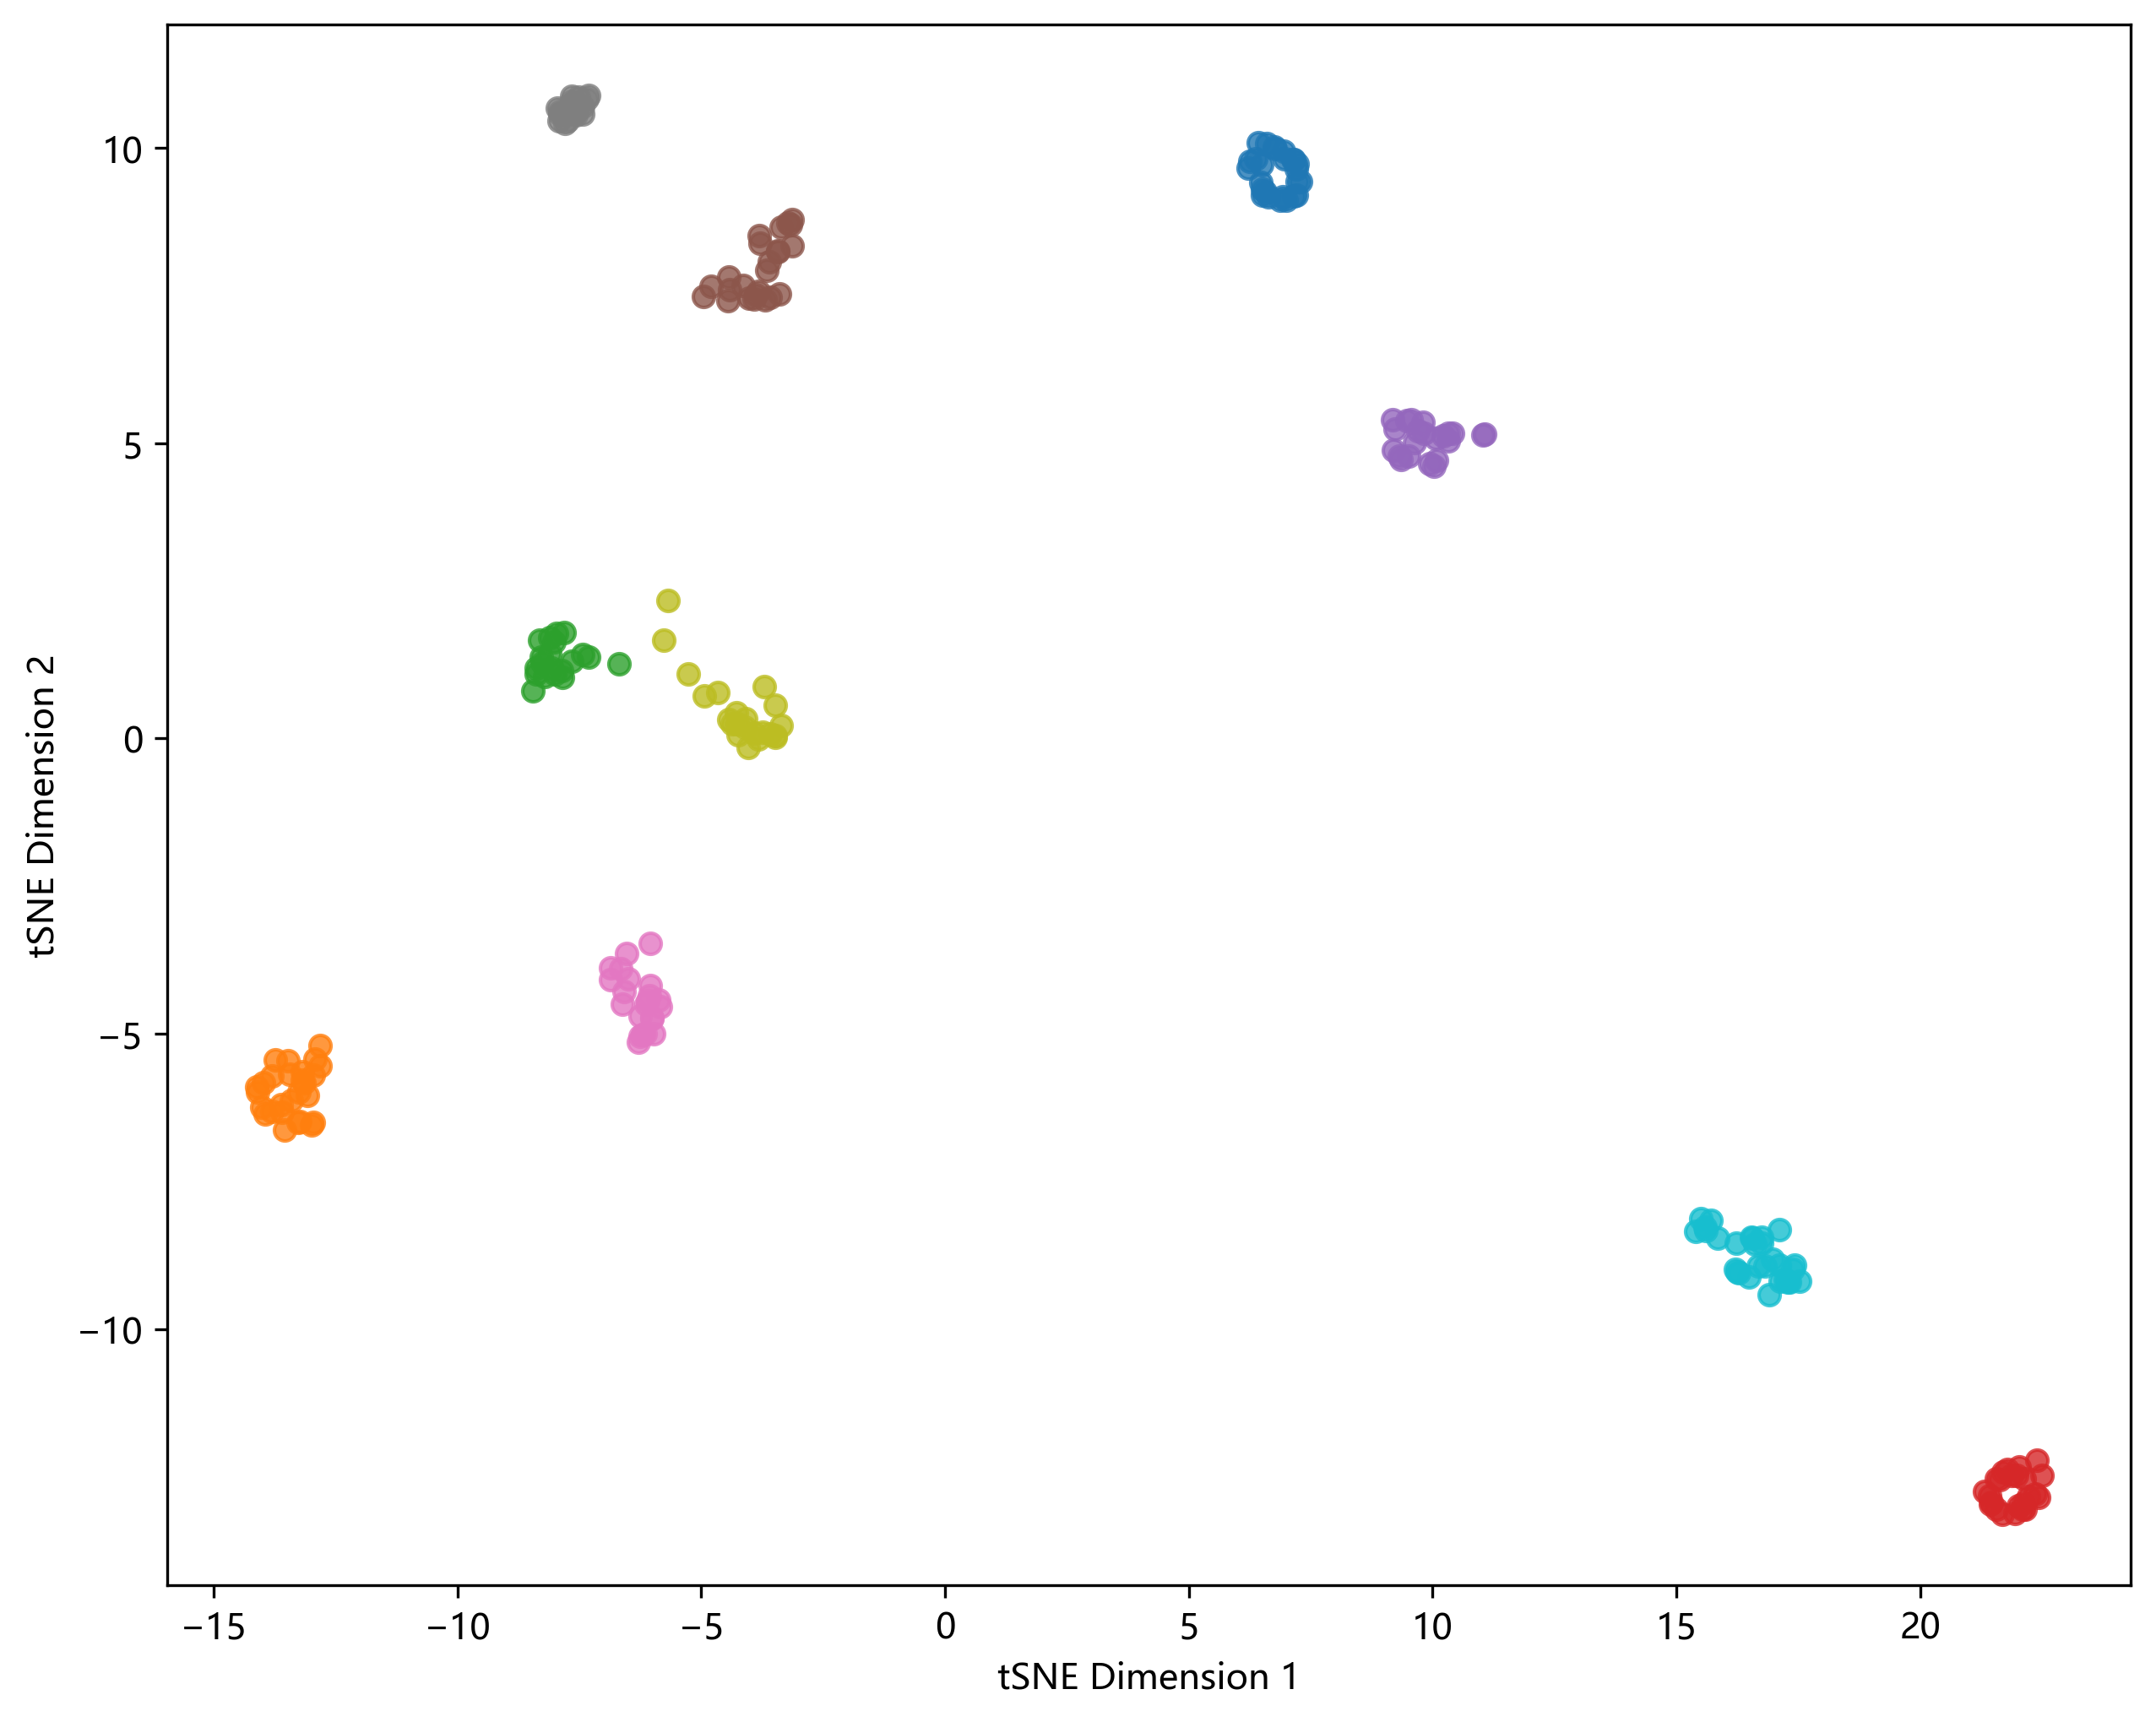

In [34]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rc("font", family='Microsoft YaHei')
from sklearn.manifold import TSNE  # 用于实现 t-SNE 降维。

# 训练好的模型 测试集 进行 t-SNE 降维
def plot_model_TSNE(test_model_features, true_labels, num_classes, class_labels_name):
    ''' 
        test_model_features  : 测试集的特征（高维数据）
        true_labels          : 测试集的原始标签
        num_classes          : 分类的类别数
        class_labels_name    : 每个类别的名称
    '''
    features = np.array(test_model_features)   # (233, 10)
    labels = np.array(true_labels)  

    # 初始化 t-SNE 模型
    # n_components=2 指定降维到二维空间。
    # random_state=42 设置随机种子
    tsne = TSNE(n_components=2, random_state=42)

    # 对原始数据进行 t-SNE 降维
    # 降维后的二维特征 features_tsne
    features_tsne = tsne.fit_transform(features) # (224, 2)

    # 可视化结果
    plt.figure(figsize=(10, 8), dpi=300)
    # 绘制每个类别的散点图，并指定label
    for i in range(num_classes):
        # 分别表示第 i 类数据在降维后二维空间的第一个和第二个坐标
        # 为每个类别指定标签，便于后续显示图例
        plt.scatter(features_tsne[labels == i, 0], features_tsne[labels == i, 1], label=class_labels_name[i], alpha=0.8)
   # plt.title('Model test set TSNE visualization')
    plt.xlabel('tSNE Dimension 1')
    plt.ylabel('tSNE Dimension 2')
    # 显示legend
    #plt.legend(fontsize=16)  # 调整此处数值以控制图例大小 
    # plt.show()
    plt.savefig('./dataresult/Model test set TSNE visualization', dpi=300)
    

num_classes = 10  # 10分类
# 类别标签
class_labels_name = ['de_normal', 'de_7_1', 'de_7_2', 'de_7_3', 'de_14_1',
                'de_14_2', 'de_14_3', 'de_21_1', 'de_21_2', 'de_21_3']

# 训练好的模型 测试集 进行 t-SNE 降维
plot_model_TSNE(test_model_features, true_labels, num_classes, class_labels_name)

(233, 1024)
(233, 2)


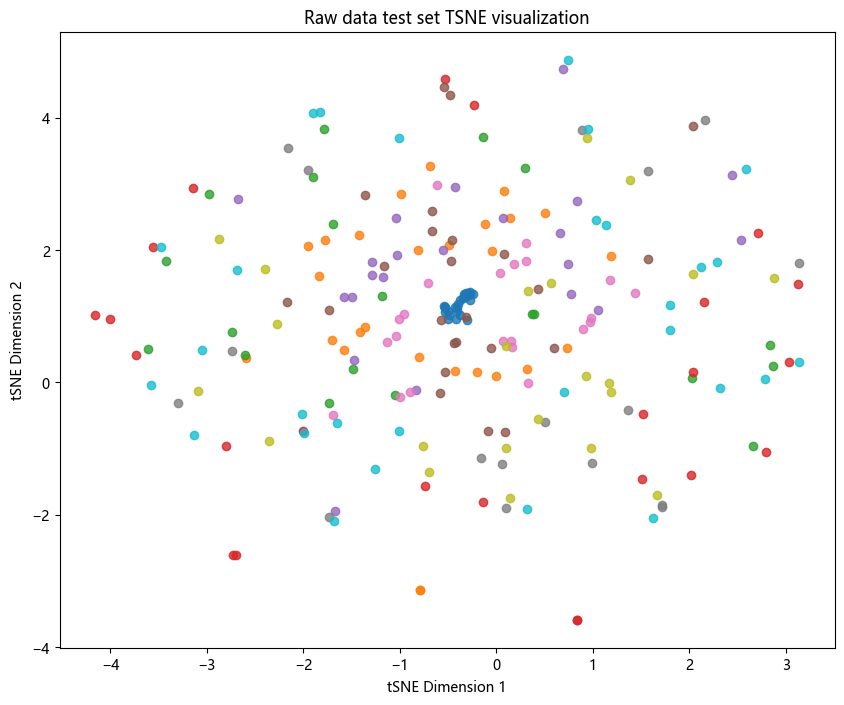

In [35]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rc("font", family='Microsoft YaHei')
from sklearn.manifold import TSNE


num_classes = 10  # 10分类
# 类别标签
class_labels_name = ['de_normal', 'de_7_1', 'de_7_2', 'de_7_3', 'de_14_1',
                'de_14_2', 'de_14_3', 'de_21_1', 'de_21_2', 'de_21_3']

# 原始 测试集 进行 t-SNE 降维
def plot_orignal_TSNE(test_original_features, true_labels, num_classes, class_labels_name):
    features = np.array(test_original_features)
    labels = np.array(true_labels)

    print(features.shape) # (233, 1024)
    # 初始化 t-SNE 模型
    tsne = TSNE(n_components=2, random_state=42)

    # 对原始数据进行 t-SNE 降维
    features_tsne = tsne.fit_transform(features)
    print(features_tsne.shape) # (233, 2)

    # 可视化结果
    plt.figure(figsize=(10, 8), dpi=100)
    # 绘制每个类别的散点图，并指定label
    for i in range(num_classes):
        plt.scatter(features_tsne[labels == i, 0], features_tsne[labels == i, 1], label=class_labels_name[i], alpha=0.8)
    plt.title('Raw data test set TSNE visualization')
    plt.xlabel('tSNE Dimension 1')
    plt.ylabel('tSNE Dimension 2')
    # 显示legend
    #plt.legend()
    # plt.show()
    plt.savefig('./dataresult/Raw data test set TSNE visualization', dpi=300)


# 原始 测试集 进行 t-SNE 降维
plot_orignal_TSNE(test_original_features, true_labels, num_classes, class_labels_name)